In [1]:
import os
import math
import wandb
import itertools
import torch
import argparse
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
from torch.func import jvp
from copy import deepcopy
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import gaussian_kde
from matplotlib.patches import Rectangle

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [2]:
def sample_checkerboard(n_samples, n_squares=4):
    assert n_squares % 2 == 0

    # sample candidate points
    x = np.random.rand(n_samples, 2)

    # map to square indices
    idx = (x * n_squares).astype(int)

    # checkerboard mask
    mask = (idx[:, 0] + idx[:, 1]) % 2 == 0

    # resample rejected points
    while not mask.all():
        n_bad = (~mask).sum()
        x_new = np.random.rand(n_bad, 2)
        idx_new = (x_new * n_squares).astype(int)

        x[~mask] = x_new
        idx[~mask] = idx_new
        mask = (idx[:, 0] + idx[:, 1]) % 2 == 0

    return 4.0 * (x - np.array([[0.5, 0.5]]))

class MeanFlowMLP(nn.Module):
    """
    u_theta(z, r, t) -> R^2
    Inputs: z in R^2, (t, r) scalars (two extra channels)
    """
    def __init__(self, hidden=256, depth=4):
        super().__init__()
        layers = []
        in_dim = 2 + 2  # z + (t, t-r)
        dim = in_dim
        for _ in range(depth):
            layers += [nn.Linear(dim, hidden), nn.SiLU()]
            dim = hidden
        layers += [nn.Linear(dim, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, z, r, t):
        # dt = t - r
        inp = torch.cat([z, t, r], dim=1)
        return self.net(inp)

class Adapter(nn.Module):
    def __init__(self, hidden=128, depth=3, z_dim=2):
        super().__init__()
        layers = []
        in_dim = 1  # y is scalar
        dim = in_dim
        for _ in range(depth):
            layers += [nn.Linear(dim, hidden), nn.SiLU()]
            dim = hidden
        self.backbone = nn.Sequential(*layers)
        self.mu = nn.Linear(dim, z_dim)
        self.log_std = nn.Linear(dim, z_dim)  # log sigma

    def forward(self, y):
        h = self.backbone(y)
        mu = self.mu(h)
        log_std = self.log_std(h).clamp(-6.0, 3.0)  # stability
        return mu, log_std

def f_theta(z, u_model, K=1):
    # z has shape (B,D) or (B,J,D)
    if z.ndim == 3:
        B, J, D = z.shape
        z = z.reshape(B * J, D)
    ts = torch.linspace(0.0, 1.0, K + 1, device=device)
    for i in range(K, 0, -1):
        t_i = torch.full((z.shape[0], 1), ts[i].item(), device=device)
        r_i = torch.full((z.shape[0], 1), ts[i-1].item(), device=device)
        z = z - (t_i - r_i) * u_model(z, r_i, t_i)
    if 'J' in locals():
        z = z.reshape(B, J, D)
    return z

In [3]:
def checkerboard_block_id(x01: torch.Tensor, n_squares=4, filled_parity=0):
    """
    x01: (N,2) points assumed in [0,1]^2
    returns:
      block_id: (N,) long tensor, -1 if outside [0,1]^2 or not a filled square
      ij: (N,2) long tensor of grid indices (i,j) (undefined when block_id=-1)
    """
    assert x01.ndim == 2 and x01.shape[1] == 2
    x = x01

    # inside unit box?
    inside = (x[:,0] >= 0) & (x[:,0] < 1) & (x[:,1] >= 0) & (x[:,1] < 1)

    ij = torch.floor(x * n_squares).long().clamp(0, n_squares-1)
    i, j = ij[:,0], ij[:,1]

    # checkerboard: keep only squares with (i+j) % 2 == filled_parity
    filled = ((i + j) % 2 == filled_parity)

    ok = inside & filled
    block_id = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
    block_id[ok] = i[ok] * n_squares + j[ok]  # unique id per grid cell

    return block_id, ij

def unscale_to_unit(x_scaled):
    return x_scaled / 4.0 + 0.5

def reparam_sample(mu, log_std, J=None):
    # mu, log_std: Shape (B, D)
    if J is None:
        eps = torch.randn_like(mu)
        z = mu + torch.exp(log_std) * eps
    else:
        # Get samples of shape (B, J, D)
        B, D = mu.shape
        eps = torch.randn(B, J, D, device=mu.device, dtype=mu.dtype)
        z = mu.unsqueeze(1) + torch.exp(log_std).unsqueeze(1) * eps
    return z
    
def sample_y(x, sigma_obs):
    # A = [1,0], so observe first coord
    y = x[:, :1] + sigma_obs * torch.randn(x.shape[0], 1, device=x.device, dtype=x.dtype)
    return y

@torch.no_grad()
def meanflow_one_step_with_latents(model, n_samples=10_000, device="cpu"):
    model.eval()
    z1 = torch.randn(n_samples, 2, device=device)
    t = torch.ones(n_samples, 1, device=device)
    r = torch.zeros(n_samples, 1, device=device)
    x0 = z1 - model(z1, r, t)
    return z1, x0

@torch.no_grad()
def meanflow_k_steps_with_latents(model, n_samples=10_000, K=10, device="cpu"):
    import math
    model.eval()
    z = torch.randn(n_samples, 2, device=device)
    z1 = z.clone()
    ts = torch.linspace(0.0, 1.0, K + 1, device=device)

    for i in range(K, 0, -1):
        t_i = torch.full((n_samples, 1), ts[i].item(), device=device)
        r_i = torch.full((n_samples, 1), ts[i-1].item(), device=device)
        z = z - (t_i - r_i) * model(z, r_i, t_i)

    x0 = z
    return z1, x0

In [4]:
# Plot utils
def compute_kde(data):
    # Ensure data is 2D and convert to numpy if it's a tensor
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()

    # If data is 1D, make it 2D by adding a column of zeros
    if data.ndim == 1:
        data = np.vstack([data, np.zeros_like(data)])
    elif data.shape[1] == 1:
        data = np.vstack([data.flatten(), np.zeros_like(data.flatten())])
    else:
        data = data[:, :2].T # Transpose for kde (2, N)
    
    # If after processing, data is still not suitable for KDE
    if data.shape[0] != 2 or data.shape[1] < 2:
        print("Data dimensions not suitable for 2D KDE.")
        return None

    # Compute KDE
    try:
        kde = gaussian_kde(data)
        return kde
    except np.linalg.LinAlgError as e:
        print(f"KDE computation failed: {e}")
        return None

def get_kde_points(data):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    xmin, ymin = data.min(axis=0)
    xmax, ymax = data.max(axis=0)
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= 0.2 * dx; xmax += 0.2 * dx
    ymin -= 0.2 * dy; ymax += 0.2 * dy

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, 100),
        np.linspace(ymin, ymax, 100),
        indexing="xy",
    )
    pts = np.column_stack([xx.ravel(), yy.ravel()])
    return pts.T, [xmin, xmax, ymin, ymax]

In [5]:
# Number of multisteps
K = 4
sigma = 0.1
B = 10000
J = 100

x_val = sample_checkerboard(B, n_squares=4)
x_val = torch.tensor(x_val, dtype=torch.float32).to(device)

def plot_noise_and_data(model, adpater, y_val):
    with torch.no_grad():
        y0 = torch.tensor([[y_val]], device=device, dtype=torch.float32)
        mu, log_std = adapter(y0.repeat(J, 1)) # (J, 2)
        z = reparam_sample(mu, log_std) # (J, 2)
        x_samp = f_theta(z, model, K).cpu() # (J, 2)
    
    z_np = z.detach().cpu().numpy()
    
    kde_z_np = compute_kde(z_np)
    z_pts, z_range = get_kde_points(z_np)
    kde_x_samp = compute_kde(x_samp)
    x_pts, x_range = get_kde_points(x_samp)
    
    dens_z = kde_z_np(z_pts)
    dens_z = np.asarray(dens_z).reshape(100, 100)
    dens_x = kde_x_samp(x_pts)
    dens_x = np.asarray(dens_x).reshape(100, 100)
    
    if K == 1:
        z1, x0 = meanflow_one_step_with_latents(model, n_samples=10_000, device=device)
    else:
        z1, x0 = meanflow_k_steps_with_latents(model, n_samples=10_000, K=K, device=device)
    
    x01 = unscale_to_unit(x0)  # map to [0,1]^2 for block assignment
    block_id, ij = checkerboard_block_id(x01, n_squares=4, filled_parity=0)
    valid = block_id >= 0
    unique_blocks = torch.unique(block_id[valid]).tolist()
    block_to_compact = {b: k for k, b in enumerate(unique_blocks)}
    labels = torch.full_like(block_id, -1)
    for b, k in block_to_compact.items():
        labels[block_id == b] = k
    
    z1_np = z1.detach().cpu().numpy()
    x01_np = x0.detach().cpu().numpy()
    lab_np = labels.detach().cpu().numpy()
    
    valid = lab_np >= 0
    invalid = ~valid
    cmap = plt.get_cmap("tab10")   # gives C0..C9
    colors = cmap(lab_np[valid] % cmap.N)
    
    # ---------- noise space ----------
    fig_z = plt.figure(figsize=(3,3))
    plt.scatter(z1_np[invalid, 0], z1_np[invalid, 1], s=3, alpha=0.6, c="lightgrey", rasterized=True)
    plt.scatter(z1_np[valid, 0], z1_np[valid, 1], s=3, alpha=0.6, c=colors, rasterized=True)
    plt.contour(dens_z, origin='lower', extent=z_range, zorder=100)
    plt.xlim(-3.2, 3.2)
    plt.ylim(-3.2, 3.2)
    ax = plt.gca()
    ax.set_xticks([])
    ax.set_yticks([])
    
    # ---------- data space ----------
    fig_x = plt.figure(figsize=(3,3))
    plt.scatter(x01_np[invalid, 0], x01_np[invalid, 1], s=3, alpha=0.4, c="lightgrey", rasterized=True)
    plt.scatter(x01_np[valid, 0], x01_np[valid, 1], s=3, alpha=0.4, c=colors, rasterized=True)
    plt.contour(dens_x, origin='lower', extent=x_range, zorder=100)
    plt.vlines(y_val, -2.2, 2.2, linestyles="dashed", colors="black")
    plt.xlim(-2.2, 2.2)
    plt.ylim(-2.2, 2.2)
    ax = plt.gca()
    squares = [(-2,-2), (-2, 0),
               (-1, 1), (-1,-1),
               ( 0, 0), ( 0,-2),
               ( 1, 1), ( 1,-1)]
    
    for (x0, y0_) in squares:
        ax.add_patch(Rectangle((x0, y0_), 1, 1,
                               fill=False, edgecolor="k",
                               linewidth=1, zorder=10, alpha=0.8))
    
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])

    return fig_z, fig_x

In [7]:
y_val = 0.5

# Main

*** Adapter only training ***


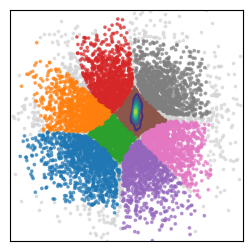

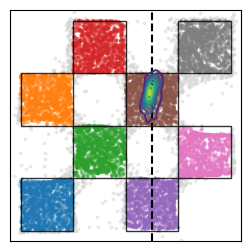

In [63]:
dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/adapter_only_model.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)
mf_ckpt = os.path.join(dir_name, "ckpts/mf_model.pt")

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt, strict=True)
model.load_state_dict(torch.load(mf_ckpt, map_location=device))

print("*** Adapter only training ***")
adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/main/adapter_only_y_{y_val}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/main/adapter_only_y_{y_val}_data.pdf", bbox_inches="tight")

*** Naive joint training ***


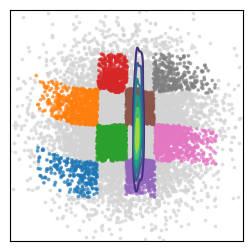

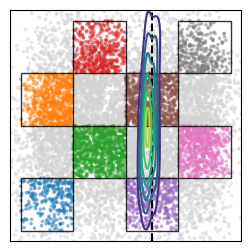

In [64]:
dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/joint_adapter_mf_model_naive.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

print("*** Naive joint training ***")
adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/main/naive_joint_y_{y_val}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/main/naive_joint_y_{y_val}_data.pdf", bbox_inches="tight")

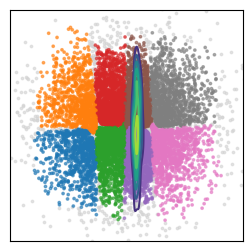

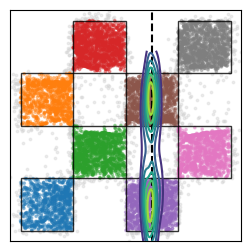

In [65]:
tau = 100.0
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/main/vfm_ema_tau_{tau}_y_{y_val}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/main/vfm_ema_{tau}_y_{y_val}_data.pdf", bbox_inches="tight")

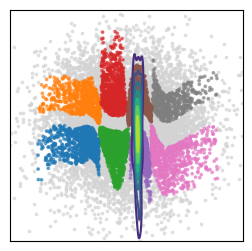

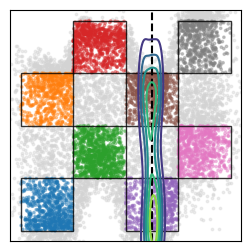

In [66]:
tau = 100.0
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/main/vfm_noema_tau_{tau}_y_{y_val}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/main/vfm_noema_tau_{tau}_y_{y_val}_data.pdf", bbox_inches="tight")

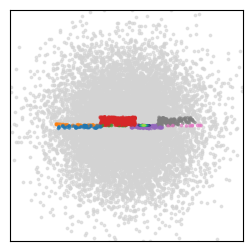

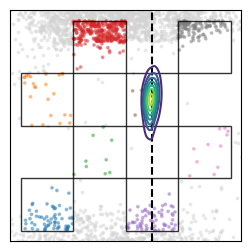

In [84]:
tau = 0.1
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/vfm_ema_tau_{tau}_y_{y_val}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/vfm_ema_tau_{tau}_y_{y_val}_data.pdf", bbox_inches="tight")

# alpha ablation

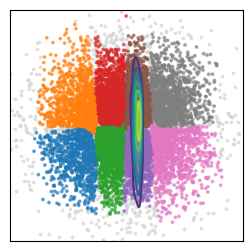

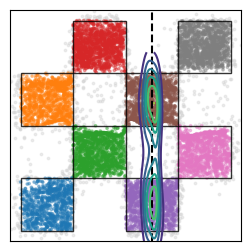

In [88]:
tau = 100.0
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_data.pdf", bbox_inches="tight")

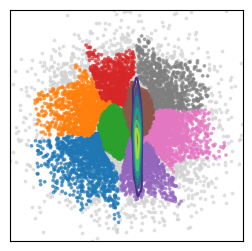

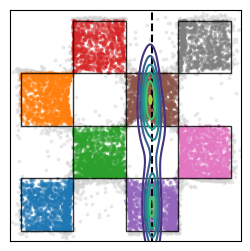

In [89]:
tau = 100.0
alpha = 0.75

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_data.pdf", bbox_inches="tight")

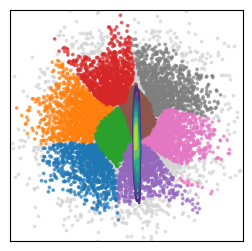

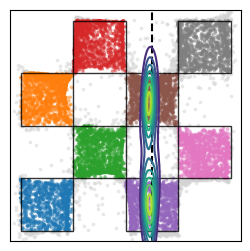

In [101]:
tau = 100.0
alpha = 0.5

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_data.pdf", bbox_inches="tight")

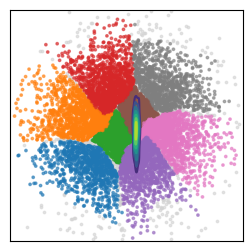

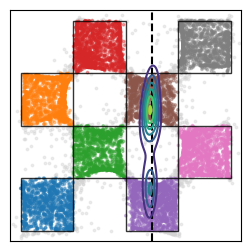

In [98]:
tau = 100.0
alpha = 0.25

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_data.pdf", bbox_inches="tight")

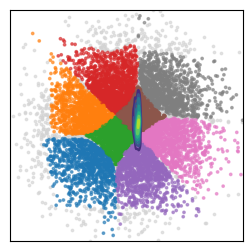

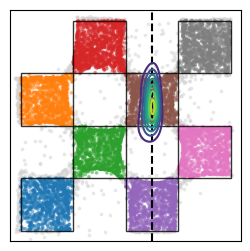

In [96]:
tau = 100.0
alpha = 0.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/alpha_ablation/vfm_ema_alpha_{alpha}_data.pdf", bbox_inches="tight")

# tau ablation

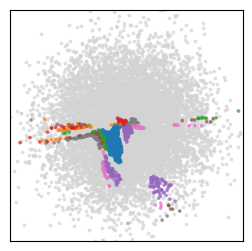

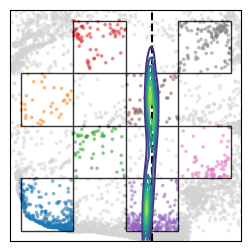

In [9]:
tau = 0.01
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_data.pdf", bbox_inches="tight")

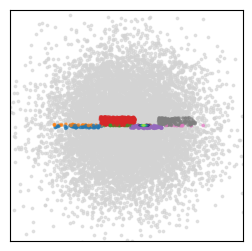

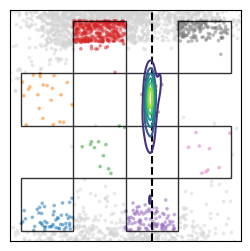

In [10]:
tau = 0.1
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_data.pdf", bbox_inches="tight")

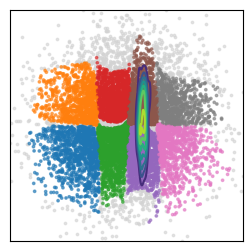

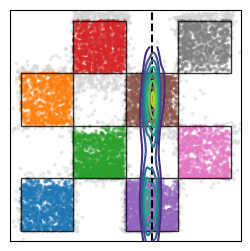

In [11]:
tau = 1.0
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_data.pdf", bbox_inches="tight")

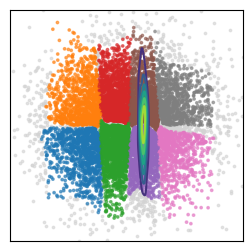

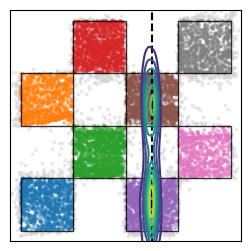

In [12]:
tau = 10.0
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_data.pdf", bbox_inches="tight")

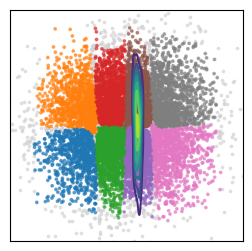

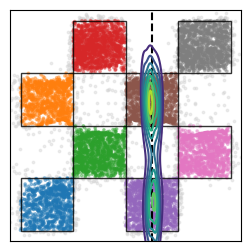

In [13]:
tau = 100.0
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/tau_ablation/vfm_ema_tau_{tau}_data.pdf", bbox_inches="tight")

# No KL

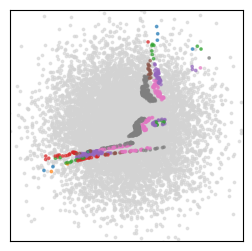

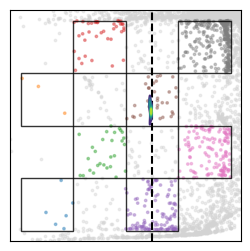

In [8]:
tau = 100.0
alpha = 1.0

dir_name = "/resnick/groups/astuart/sotakao/adapter-dmf/checkerboard_example"
fname = f"ckpts/vfm_adapter_tau_{tau}_alpha_{alpha}_ema_no_kl.pt"
ckpt_path = os.path.join(dir_name, fname)
ckpt = torch.load(ckpt_path)

model = MeanFlowMLP(hidden=512, depth=6).to(device)
adapter = Adapter(hidden=256, depth=4, z_dim=2).to(device)

adapter.load_state_dict(ckpt["adapter"], strict=True)
model.load_state_dict(ckpt["mf_model"], strict=True)

adapter.eval()
model.eval()

fig_z, fig_x = plot_noise_and_data(model, adapter, y_val)
fig_z.savefig(f"figures/viz/vfm_no_kl_tau_{tau}_y_{y_val}_latent.pdf", bbox_inches="tight")
fig_x.savefig(f"figures/viz/vfm_no_kl_tau_{tau}_y_{y_val}_data.pdf", bbox_inches="tight")